# Attention Pattern Visualization — Interactive Head Explorer

Interactive notebook to explore attention patterns of **any head in any layer** of
LLaVA 1.5 7B's language model across **30 randomly selected images** from the POPE
evaluation set.

**Use the widgets in §6 to pick the layer and head** — nothing is hardcoded.

**Visualisation style** (matching `path_patching_single_sample.ipynb`):
- Left panel: CLIP-preprocessed image (336×336)
- Right panel: image + attention heatmap overlay (jet colormap)
- Below: text tokens coloured by attention weight (Reds colormap), with summary
  statistics (∑ image, ∑ text, self)

**How it works:**
- When you select an image, a single forward pass captures Q/K for **all 32 layers**.
- Switching layer / head / query position is then instant — attention is recomputed
  from the cached Q/K without re-running the model.
- Switching images triggers a new forward pass (~1–2 s).

## 1. Configuration & Imports

In [1]:
import json
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from IPython.display import HTML, display
from PIL import Image
from tqdm.auto import tqdm

import ipywidgets as widgets

torch.set_grad_enabled(False)
torch.autograd.grad_mode.set_grad_enabled(mode=False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [2]:
# ============================================================================
# CONFIGURATION — edit these before running
# ============================================================================

# --- Model ---
MODEL_ID = "llava-hf/llava-1.5-7b-hf"

# --- Image source ---
# Directory containing COCO val2014 images (used by POPE eval)
IMAGE_ROOT = Path("../data/coco2014/val2014/val2014")
# POPE file that references the images above
POPE_FILE = Path("../pope/coco_pope_adversarial.json")
# Model answers file (must match the POPE file's strategy: random/popular/adversarial)
RESULTS_FILE = Path("../results/train/llava15_7b_adversarial_train.jsonl")

# --- Filter by model correctness ---
# "all" = no filter
# "tp"  = true positive  (label=yes, pred=yes) — model correctly sees the object
# "tn"  = true negative  (label=no,  pred=no)  — model correctly rejects the object
# "fp"  = false positive (label=no,  pred=yes) — model hallucinates
# "fn"  = false negative (label=yes, pred=no)  — model misses the object
FILTER_CATEGORY = "tp"

# --- Sampling ---
NUM_IMAGES = 30
SEED = 42

# --- Prompt ---
# Use the POPE question from the dataset (True) or a fixed prompt (False)
USE_POPE_QUESTION = True
FIXED_PROMPT = "Describe this image."

# --- Query token for attention ---
# 'last'   = last token position
# 'assistant' = first token after "ASSISTANT:"
# <int>    = specific position index
QUERY_MODE = "last"

# --- Quantization ---
USE_4BIT = False

# ============================================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 2. Load Model

In [3]:
from transformers import AutoProcessor, BitsAndBytesConfig
from nnsight import VisionLanguageModel

print("Loading processor...")
processor = AutoProcessor.from_pretrained(MODEL_ID)

if USE_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )
else:
    bnb_config = None

print(f"Loading model: {MODEL_ID} ...")
model = VisionLanguageModel(
    MODEL_ID,
    quantization_config=bnb_config if USE_4BIT else None,
    dispatch=True,
    device_map="auto",
)
print("Model loaded.")

# Extract model dimensions
N_LAYERS = model.config.text_config.num_hidden_layers
N_HEADS  = model.config.text_config.num_attention_heads
D_MODEL  = model.config.text_config.hidden_size
D_HEAD   = D_MODEL // N_HEADS

print(f"L={N_LAYERS}, H={N_HEADS}, d_model={D_MODEL}, d_head={D_HEAD}")

Loading processor...
Loading model: llava-hf/llava-1.5-7b-hf ...


Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

Model loaded.
L=32, H=32, d_model=4096, d_head=128


## 3. Select 30 Random Images from POPE

In [4]:
# ---------------------------------------------------------------------------
# Load POPE labels and model answers, then filter by TP/TN/FP/FN
# ---------------------------------------------------------------------------

# 1. Load POPE ground-truth labels (JSONL)
with open(POPE_FILE) as f:
    pope_data = [json.loads(line) for line in f if line.strip()]
print(f"Loaded {len(pope_data)} questions from {POPE_FILE}")

# 2. Load model answers
with open(RESULTS_FILE) as f:
    results_data = [json.loads(line) for line in f if line.strip()]
print(f"Loaded {len(results_data)} answers from {RESULTS_FILE}")

# 3. Join on question_id: build a lookup from question_id → (image, label, pred)
results_by_id = {r["question_id"]: r for r in results_data}

id_to_info = {}
for item in pope_data:
    qid = item["question_id"]
    if qid not in results_by_id:
        continue
    label = item["label"]       # "yes" | "no"
    pred  = results_by_id[qid]["answer"]  # "yes" | "no"
    cat = None
    if label == "yes" and pred == "yes":
        cat = "tp"
    elif label == "no" and pred == "no":
        cat = "tn"
    elif label == "no" and pred == "yes":
        cat = "fp"
    elif label == "yes" and pred == "no":
        cat = "fn"
    img_name = item["image"]
    id_to_info[qid] = {
        "img_name": img_name,
        "question": item["text"],
        "label": label,
        "pred": pred,
        "category": cat,
    }

print(f"Matched {len(id_to_info)} question_id → (image, label, pred)")

# 4. Distribution
cat_counts = {"tp": 0, "tn": 0, "fp": 0, "fn": 0}
for info in id_to_info.values():
    cat_counts[info["category"]] += 1
print(f"TP={cat_counts['tp']}  TN={cat_counts['tn']}  FP={cat_counts['fp']}  FN={cat_counts['fn']}")

# 5. Group by image: keep the first question_id per image
image_to_qid = {}
for qid, info in sorted(id_to_info.items()):
    if info["img_name"] not in image_to_qid:
        image_to_qid[info["img_name"]] = qid

print(f"{len(image_to_qid)} unique images")

# 6. Filter images by category
if FILTER_CATEGORY == "all":
    candidate_images = sorted(image_to_qid.keys())
else:
    candidate_images = sorted(
        img for img in image_to_qid
        if id_to_info[image_to_qid[img]]["category"] == FILTER_CATEGORY
    )
    print(f"After filtering by '{FILTER_CATEGORY}': {len(candidate_images)} images remain")

# 7. Check which images exist on disk
available_images = []
for img_name in candidate_images:
    if (IMAGE_ROOT / img_name).exists():
        available_images.append(img_name)

print(f"{len(available_images)} images found on disk")

# 8. Sample
if len(available_images) < NUM_IMAGES:
    print(f"WARNING: Only {len(available_images)} images available, using all of them")
    selected_images = available_images
else:
    selected_images = random.sample(available_images, NUM_IMAGES)

print(f"Selected {len(selected_images)} images")
print("\n".join(f"  {i+1:2d}. {name}  [{id_to_info[image_to_qid[name]]['category'].upper()}] "
                f"Q: {id_to_info[image_to_qid[name]]['question']}"
                for i, name in enumerate(selected_images[:10])))
if len(selected_images) > 10:
    print(f"  ... and {len(selected_images) - 10} more")

# Build image_to_question lookup (used later for prompt selection)
image_to_question = {
    img: id_to_info[image_to_qid[img]]["question"]
    for img in selected_images
}

Loaded 3000 questions from ../pope/coco_pope_adversarial.json
Loaded 10002 answers from ../results/train/llava15_7b_adversarial_train.jsonl
Matched 3000 question_id → (image, label, pred)
TP=1398  TN=1006  FP=494  FN=102
500 unique images
After filtering by 'tp': 460 images remain
460 images found on disk
Selected 30 images
   1. COCO_val2014_000000017379.jpg  [TP] Q: Is there a tv in the image?
   2. COCO_val2014_000000485485.jpg  [TP] Q: Is there a person in the image?
   3. COCO_val2014_000000201148.jpg  [TP] Q: Is there a traffic light in the image?
   4. COCO_val2014_000000188958.jpg  [TP] Q: Is there a snowboard in the image?
   5. COCO_val2014_000000170077.jpg  [TP] Q: Is there a person in the image?
   6. COCO_val2014_000000105732.jpg  [TP] Q: Is there a backpack in the image?
   7. COCO_val2014_000000482476.jpg  [TP] Q: Is there a person in the image?
   8. COCO_val2014_000000079446.jpg  [TP] Q: Is there a sink in the image?
   9. COCO_val2014_000000446651.jpg  [TP] Q: Is ther

## 4. Helper Functions

In [5]:
def build_inputs(image: Image.Image, prompt_text: str) -> dict:
    """Build LLaVA inputs for a single image + prompt."""
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt_text},
            ],
        }
    ]
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    return {k: v.to(model.device) for k, v in inputs.items()}


def find_visual_span(input_ids_tensor) -> tuple:
    """Locate the 576 visual-token run in the tokenised input."""
    IMAGE_TOKEN_ID = (
        model.config.image_token_index
        if hasattr(model.config, "image_token_index") else 32000
    )
    ids = input_ids_tensor[0].detach().cpu().tolist()
    run_start = None
    for i, tid in enumerate(ids):
        if tid == IMAGE_TOKEN_ID:
            if run_start is None:
                run_start = i
            if i - run_start + 1 >= 576:
                return run_start, run_start + 576
        else:
            run_start = None
    raise RuntimeError("Visual span (expected 576 image tokens) not found.")


def preprocessed_image_336(pil_img: Image.Image) -> Image.Image:
    """Resize and centre-crop to 336×336, matching LLaVA's CLIP preprocessor."""
    W, H = pil_img.size
    if W < H:
        new_W = 336
        new_H = int(round(H * 336 / W))
    else:
        new_H = 336
        new_W = int(round(W * 336 / H))
    resized = pil_img.resize((new_W, new_H), Image.BICUBIC)
    left = (new_W - 336) // 2
    top  = (new_H - 336) // 2
    return resized.crop((left, top, left + 336, top + 336))


def _rotate_half(x: torch.Tensor) -> torch.Tensor:
    """RoPE helper: rotate the first half of dimensions against the second half."""
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)


def render_text_heatmap(weights: np.ndarray, tokens: list, vis_span: tuple, max_w: float) -> str:
    """Render text tokens as HTML with background colour = attention weight.

    Uses the 'Reds' colormap.  Image-token span is collapsed into a single
    `[IMAGE×576]` badge so the text heatmap stays readable.
    """
    cmap = plt.get_cmap("Reds")
    parts = []

    for i, (w, tok) in enumerate(zip(weights, tokens)):
        if vis_span[0] <= i < vis_span[1]:
            if i == vis_span[0]:
                parts.append(
                    '<span style="background:#444;color:white;padding:2px 4px;margin:1px;'
                    'border-radius:3px;font-size:11px">'
                    f'[IMAGE×{vis_span[1] - vis_span[0]}]</span>'
                )
            continue

        intensity = (w / max_w) if max_w > 0 else 0
        r, g, b, _ = cmap(min(1.0, intensity))
        bg = f"rgba({int(r*255)},{int(g*255)},{int(b*255)},{0.15 + 0.85*intensity:.2f})"
        text_color = "white" if intensity > 0.55 else "black"
        safe = (
            tok.replace("&", "&amp;")
            .replace("<", "&lt;")
            .replace(">", "&gt;")
            .replace(" ", "&nbsp;")
            .replace("\n", "↵")
        )
        parts.append(
            f'<span title="i={i} w={w:.4f}" '
            f'style="background:{bg};color:{text_color};padding:1px 2px;margin:0;'
            f'border-radius:2px;font-family:monospace;font-size:12px">{safe}</span>'
        )

    return "".join(parts)


# ---------------------------------------------------------------------------
# Q/K cache for the *currently selected* image (lazy, one image at a time)
# ---------------------------------------------------------------------------
_qk_cache = {
    "image_idx": None,   # which image index is currently cached
    "Q": None,           # dict[int, Tensor]  layer -> (T, N_HEADS, D_HEAD) float16 cpu
    "K": None,           # dict[int, Tensor]  layer -> (T, N_HEADS, D_HEAD) float16 cpu
    "rope_cos": None,    # (T, D_HEAD) float32 cpu
    "rope_sin": None,    # (T, D_HEAD) float32 cpu
}


def trace_all_layers(image_idx: int):
    """Run one forward pass and cache Q/K for ALL 32 layers of `image_idx`.

    Only called when the user switches to a different image.  The trace uses
    ``nnsight`` to save every layer's ``q_proj`` / ``k_proj`` output in a single
    forward pass, then moves them to CPU float16 to keep GPU memory free.
    """
    global _qk_cache

    if _qk_cache["image_idx"] == image_idx:
        return  # already cached

    rec = records[image_idx]
    inputs = rec["inputs"]
    T = rec["T"]

    # Trace: save q_proj and k_proj output for every layer
    q_proxies = []
    k_proxies = []
    with model.trace(**inputs):
        for layer in model.model.language_model.layers:
            q_proxies.append(layer.self_attn.q_proj.output.save())
            k_proxies.append(layer.self_attn.k_proj.output.save())

    # Reshape & move to CPU float16
    Q_cache = {}
    K_cache = {}
    for L_idx, (qp, kp) in enumerate(zip(q_proxies, k_proxies)):
        Q_cache[L_idx] = qp.detach().reshape(1, T, N_HEADS, D_HEAD)[0].to(
            torch.float16).cpu()
        K_cache[L_idx] = kp.detach().reshape(1, T, N_HEADS, D_HEAD)[0].to(
            torch.float16).cpu()

    # Pre-compute RoPE cos/sin for this sequence length
    rotary = model.model.language_model.rotary_emb
    position_ids = torch.arange(T, device=qp.device).unsqueeze(0)
    # Use a dummy query tensor shaped (1, T, D_HEAD) to call rotary
    q_dummy = Q_cache[0][:, 0, :].unsqueeze(0).float().to(qp.device)
    cos, sin = rotary(q_dummy, position_ids)
    rope_cos = cos[0].float().cpu()  # (T, D_HEAD)
    rope_sin = sin[0].float().cpu()  # (T, D_HEAD)

    _qk_cache = {
        "image_idx": image_idx,
        "Q": Q_cache,
        "K": K_cache,
        "rope_cos": rope_cos,
        "rope_sin": rope_sin,
    }


def compute_attention(layer: int, head: int, query_pos: int) -> np.ndarray:
    """Compute the attention pattern for (layer, head) at query_pos.

    Uses the cached Q/K from ``trace_all_layers()`` — must be called after the
    cache is populated for the current image.

    Returns (T,) numpy array = attention weights from query_pos to all keys.
    """
    T = _qk_cache["Q"][layer].shape[0]

    q = _qk_cache["Q"][layer][query_pos, head, :].float()       # (D_HEAD,)
    k = _qk_cache["K"][layer][:, head, :].float()               # (T, D_HEAD)
    cos = _qk_cache["rope_cos"]
    sin = _qk_cache["rope_sin"]

    # Apply RoPE
    q_rot = q * cos[query_pos] + _rotate_half(q) * sin[query_pos]  # (D_HEAD,)
    k_rot = k * cos + _rotate_half(k) * sin                         # (T, D_HEAD)

    scores = q_rot @ k_rot.transpose(-1, -2) / math.sqrt(D_HEAD)   # (T,)
    causal_mask = torch.arange(T) > query_pos
    scores = scores.masked_fill(causal_mask, float("-inf"))
    return F.softmax(scores, dim=-1).numpy()

## 5. Pre-process All 30 Images (Tokenise, No Model Tracing Yet)

In [6]:
def resolve_query_position(ids_list: list, T: int, mode: str) -> int:
    """Return the default query token index for the given mode."""
    if mode == "last":
        return T - 1
    elif mode == "assistant":
        assist_ids = processor.tokenizer.encode("ASSISTANT:", add_special_tokens=False)
        for i in range(len(ids_list) - len(assist_ids) + 1):
            if ids_list[i:i + len(assist_ids)] == assist_ids:
                return i + len(assist_ids)
        return T - 1  # fallback
    elif isinstance(mode, int):
        return min(mode, T - 1)
    else:
        raise ValueError(f"Unknown QUERY_MODE: {mode!r}")


records = []  # list of dicts — one per image, NO attention data yet

for idx, img_name in enumerate(tqdm(selected_images, desc="Pre-processing images")):
    img_path = IMAGE_ROOT / img_name
    pil_img = Image.open(img_path).convert("RGB")

    # Choose prompt
    prompt = image_to_question[img_name] if USE_POPE_QUESTION else FIXED_PROMPT

    # Tokenise
    inputs = build_inputs(pil_img, prompt)
    input_ids = inputs["input_ids"]
    T = input_ids.shape[1]

    # Locate visual span
    vis_span = find_visual_span(input_ids)

    # Token list for text rendering
    ids_list = input_ids[0].detach().cpu().tolist()
    toks_list = [processor.tokenizer.decode([tid]) for tid in ids_list]

    # Preprocessed image for overlay
    img_336 = preprocessed_image_336(pil_img)

    # Default query position
    query_pos = resolve_query_position(ids_list, T, QUERY_MODE)

    records.append({
        "img_name": img_name,
        "prompt": prompt,
        "pil_img": pil_img,
        "img_336": img_336,
        "T": T,
        "vis_span": vis_span,
        "tokens": toks_list,
        "ids": ids_list,
        "inputs": inputs,
        "query_pos": query_pos,
    })

print(f"\nPre-processed {len(records)} images (tokenised, no model traces yet).")
print("Query positions (first 5):")
for i, rec in enumerate(records[:5]):
    qp = rec["query_pos"]
    print(f"  {i+1}. {rec['img_name']}: pos={qp}, token={rec['tokens'][qp]!r}")
if len(records) > 5:
    print(f"  ... and {len(records)-5} more")

Pre-processing images:   0%|          | 0/30 [00:00<?, ?it/s]


Pre-processed 30 images (tokenised, no model traces yet).
Query positions (first 5):
  1. COCO_val2014_000000017379.jpg: pos=595, token=':'
  2. COCO_val2014_000000485485.jpg: pos=595, token=':'
  3. COCO_val2014_000000201148.jpg: pos=596, token=':'
  4. COCO_val2014_000000188958.jpg: pos=596, token=':'
  5. COCO_val2014_000000170077.jpg: pos=595, token=':'
  ... and 25 more


## 6. Interactive Dashboard

**Controls:**
- **Image**: select which of the 30 images to display (triggers a forward pass → ~1–2 s)
- **Layer**: 0–31 (instant — recomputes attention from cached Q/K)
- **Head**: 0–31 (instant)
- **Query**: token position slider (instant)

For each selection we show:
- **Left**: CLIP-preprocessed image (336×336)
- **Right**: image with attention heatmap overlay (jet colormap)
- **Below**: text tokens with background colour intensity ∝ attention weight
- **Summary line**: ∑ image | ∑ text | self (query→query) attention mass

In [7]:
def visualise_attention(img_idx: int, layer: int, head: int, query_pos: int):
    """Render the attention visualisation.

    If the Q/K cache is stale (different image), traces the model first.
    """
    # Ensure Q/K cache is warm for this image
    if _qk_cache["image_idx"] != img_idx:
        trace_all_layers(img_idx)

    rec = records[img_idx]
    T_cur = rec["T"]
    vis_span = rec["vis_span"]
    tokens = rec["tokens"]
    img_336 = rec["img_336"]

    if query_pos >= T_cur:
        query_pos = T_cur - 1

    # Compute attention for the selected (layer, head, query_pos)
    attn_row = compute_attention(layer, head, query_pos)

    # Split into visual and text portions
    vis_attn_flat = attn_row[vis_span[0]:vis_span[1]]
    vis_attn_2d = vis_attn_flat.reshape(24, 24)

    text_mask = np.ones(T_cur, dtype=bool)
    text_mask[vis_span[0]:vis_span[1]] = False
    text_attn = attn_row * text_mask

    total_img   = float(vis_attn_flat.sum())
    total_text  = float(text_attn.sum())
    total_self  = float(attn_row[query_pos])

    # ---- Matplotlib figure ----
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    axes[0].imshow(img_336)
    axes[0].set_title(
        f"Preprocessed image (CLIP 336×336)\n{rec['img_name']}",
        fontsize=10,
    )
    axes[0].axis("off")

    # Upsample 24×24 → 336×336 for smooth overlay
    img_arr = np.array(img_336)
    H_img, W_img = img_arr.shape[:2]
    heat_up = np.array(
        Image.fromarray(
            (vis_attn_2d / (vis_attn_2d.max() + 1e-12) * 255).astype(np.uint8)
        ).resize((W_img, H_img), Image.BILINEAR)
    )
    axes[1].imshow(img_arr)
    axes[1].imshow(heat_up, cmap="jet", alpha=0.55)
    axes[1].set_title(
        f"Attention overlay — L{layer}.H{head}\n"
        f"Query [{query_pos}]: {tokens[query_pos]!r} | "
        f"Prompt: {rec['prompt'][:60]}...\n"
        f"∑ image = {total_img:.3f}  |  ∑ text = {total_text:.3f}  |  "
        f"self = {total_self:.3f}",
        fontsize=9,
    )
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    # ---- Text token heatmap ----
    max_text_w = float(text_attn.max()) if text_attn.max() > 0 else 1.0
    html = render_text_heatmap(attn_row, tokens, vis_span, max_text_w)
    display(
        HTML(
            '<div style="margin-top:8px">'
            '<b>Text tokens</b> — background ∝ attention weight '
            f'(normalised over text; max text w = {max_text_w:.4f})</div>'
            f'<div style="line-height:1.9;padding:6px;border:1px solid #ddd;'
            f'border-radius:4px;background:#fafafa">{html}</div>'
            '<div style="margin-top:6px;font-family:monospace;font-size:12px">'
            f'∑ image = {total_img:.4f} &nbsp;|&nbsp; '
            f'∑ text = {total_text:.4f} &nbsp;|&nbsp; '
            f'self(query→query) = {total_self:.4f}</div>'
        )
    )


# ---- Build widgets ----
image_options = [
    (f"{i+1:2d}. {rec['img_name']}", i)
    for i, rec in enumerate(records)
]

max_T = max(rec["T"] for rec in records)

img_dd = widgets.Dropdown(
    options=image_options,
    value=0,
    description="Image:",
    layout=widgets.Layout(width="520px"),
)

layer_sl = widgets.IntSlider(
    value=19, min=0, max=N_LAYERS - 1, step=1,
    description="Layer:",
    layout=widgets.Layout(width="700px"),
)

head_sl = widgets.IntSlider(
    value=14, min=0, max=N_HEADS - 1, step=1,
    description="Head:",
    layout=widgets.Layout(width="700px"),
)

query_sl = widgets.IntSlider(
    value=records[0]["query_pos"],
    min=0,
    max=max_T - 1,
    step=1,
    description="Query:",
    layout=widgets.Layout(width="700px"),
)

# Update slider max when image changes; reset query to default for that image
def _on_img_change(change):
    idx = change["new"]
    query_sl.max = records[idx]["T"] - 1
    query_sl.value = records[idx]["query_pos"]

img_dd.observe(_on_img_change, names="value")

ui = widgets.VBox([
    img_dd,
    widgets.HBox([layer_sl, head_sl]),
    query_sl,
])
out = widgets.interactive_output(
    lambda Image, Layer, Head, Query: visualise_attention(Image, Layer, Head, Query),
    {"Image": img_dd, "Layer": layer_sl, "Head": head_sl, "Query": query_sl},
)
display(ui, out)

Output()

## 7. Summary: Attention Mass Distribution Across Images

Aggregate statistics showing how the **currently selected head** distributes
attention between image and text tokens across all 30 images.

Run this cell after picking a (layer, head) in the dashboard above.  It reads
the current slider values.

Computing summary for L19.H14 across 30 images ...


Computing attention:   0%|          | 0/30 [00:00<?, ?it/s]

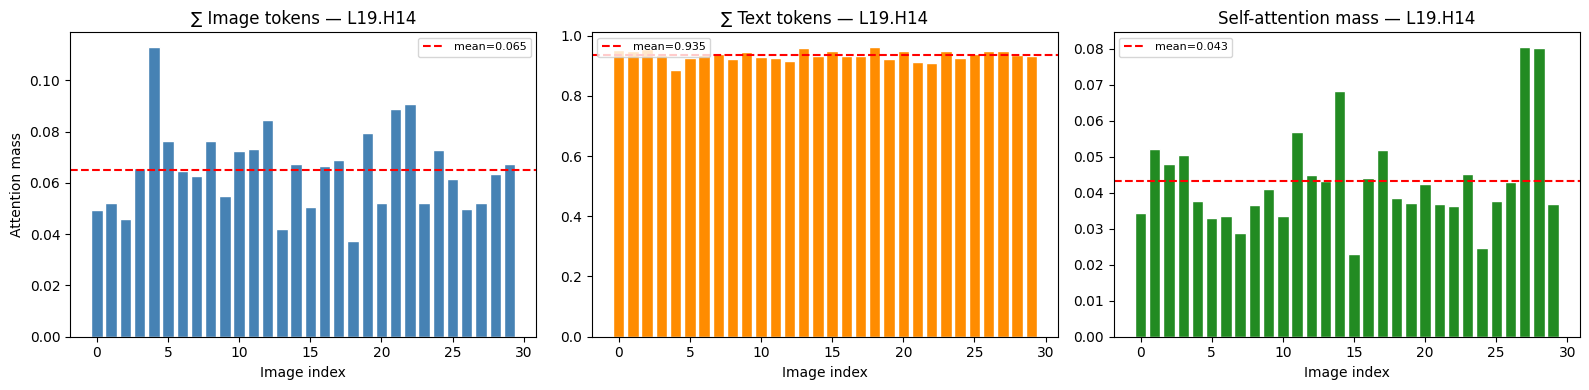


Aggregate stats across 30 images (head L19.H14):
  Image mass:  mean=0.0652, std=0.0160, range=[0.0375, 0.1131]
  Text mass:   mean=0.9348, std=0.0160, range=[0.8869, 0.9625]
  Self mass:   mean=0.0434, std=0.0135, range=[0.0231, 0.0806]
  Image / Text ratio: mean=0.07


In [8]:
cur_layer = layer_sl.value
cur_head  = head_sl.value

print(f"Computing summary for L{cur_layer}.H{cur_head} across {len(records)} images ...")

summary = []
for img_idx in tqdm(range(len(records)), desc="Computing attention"):
    # Ensure Q/K cache is warm
    if _qk_cache["image_idx"] != img_idx:
        trace_all_layers(img_idx)

    rec = records[img_idx]
    qp = rec["query_pos"]
    vis_span = rec["vis_span"]

    attn_row = compute_attention(cur_layer, cur_head, qp)

    img_mass  = float(attn_row[vis_span[0]:vis_span[1]].sum())
    text_mask = np.ones(rec["T"], dtype=bool)
    text_mask[vis_span[0]:vis_span[1]] = False
    text_mass = float((attn_row * text_mask).sum())
    self_mass = float(attn_row[qp])

    summary.append({
        "img_name": rec["img_name"],
        "img_mass": img_mass,
        "text_mass": text_mass,
        "self_mass": self_mass,
        "T": rec["T"],
        "query_pos": qp,
        "query_token": rec["tokens"][qp],
    })

img_masses  = [s["img_mass"] for s in summary]
text_masses = [s["text_mass"] for s in summary]
self_masses = [s["self_mass"] for s in summary]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(range(len(summary)), img_masses, color="steelblue", edgecolor="white")
axes[0].axhline(y=np.mean(img_masses), color="red", linestyle="--",
                label=f"mean={np.mean(img_masses):.3f}")
axes[0].set_xlabel("Image index")
axes[0].set_ylabel("Attention mass")
axes[0].set_title(f"∑ Image tokens — L{cur_layer}.H{cur_head}")
axes[0].legend(fontsize=8)

axes[1].bar(range(len(summary)), text_masses, color="darkorange", edgecolor="white")
axes[1].axhline(y=np.mean(text_masses), color="red", linestyle="--",
                label=f"mean={np.mean(text_masses):.3f}")
axes[1].set_xlabel("Image index")
axes[1].set_title(f"∑ Text tokens — L{cur_layer}.H{cur_head}")
axes[1].legend(fontsize=8)

axes[2].bar(range(len(summary)), self_masses, color="forestgreen", edgecolor="white")
axes[2].axhline(y=np.mean(self_masses), color="red", linestyle="--",
                label=f"mean={np.mean(self_masses):.3f}")
axes[2].set_xlabel("Image index")
axes[2].set_title(f"Self-attention mass — L{cur_layer}.H{cur_head}")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nAggregate stats across {len(summary)} images "
      f"(head L{cur_layer}.H{cur_head}):")
print(f"  Image mass:  mean={np.mean(img_masses):.4f}, "
      f"std={np.std(img_masses):.4f}, "
      f"range=[{np.min(img_masses):.4f}, {np.max(img_masses):.4f}]")
print(f"  Text mass:   mean={np.mean(text_masses):.4f}, "
      f"std={np.std(text_masses):.4f}, "
      f"range=[{np.min(text_masses):.4f}, {np.max(text_masses):.4f}]")
print(f"  Self mass:   mean={np.mean(self_masses):.4f}, "
      f"std={np.std(self_masses):.4f}, "
      f"range=[{np.min(self_masses):.4f}, {np.max(self_masses):.4f}]")
ratio = np.mean(np.array(img_masses) / (np.array(text_masses) + 1e-12))
print(f"  Image / Text ratio: mean={ratio:.2f}")

## 8. Gallery: Attention Overlays for All 30 Images

A static grid showing every image with its attention overlay for the
**currently selected head** (reads slider values from the dashboard).
Useful for scanning across the whole batch at once.

Building gallery for L19.H14 ...


Computing gallery:   0%|          | 0/30 [00:00<?, ?it/s]

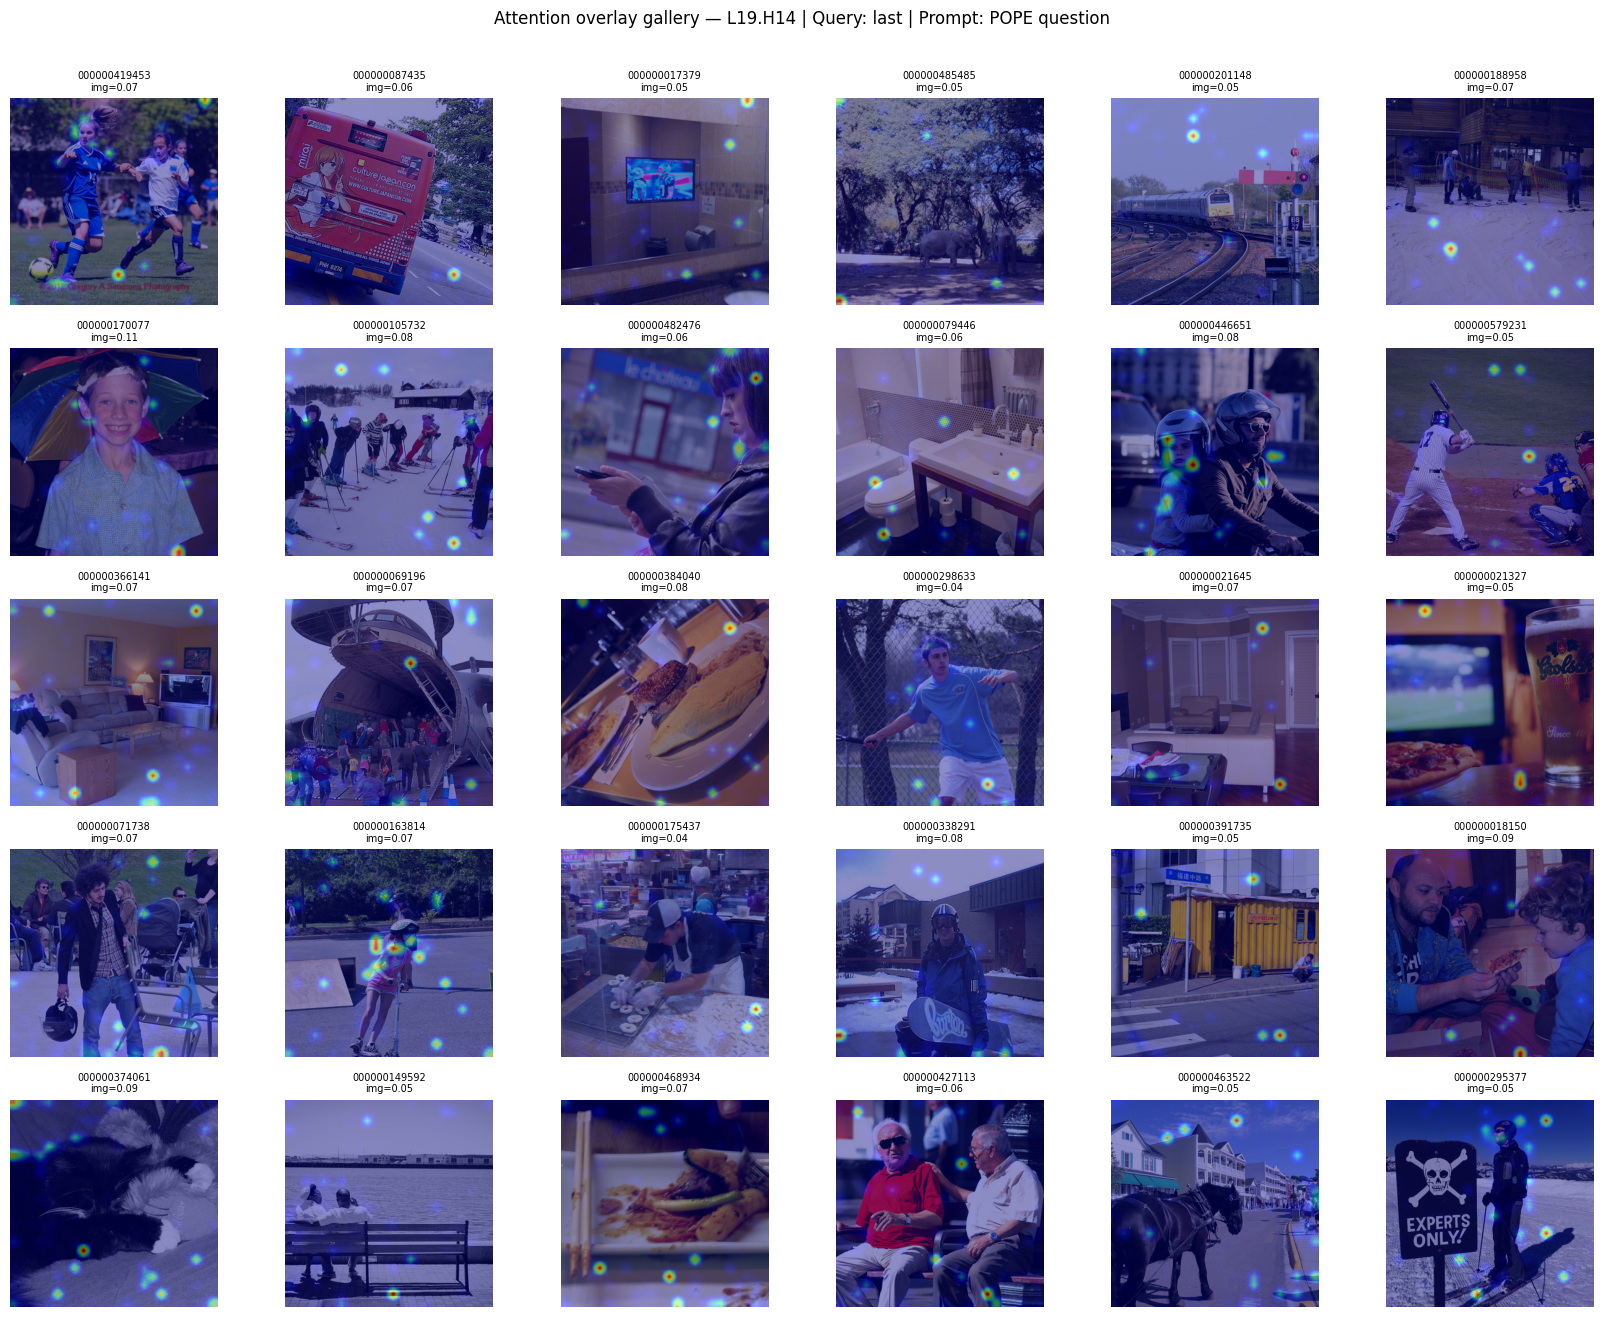

In [9]:
cur_layer_gal = layer_sl.value
cur_head_gal  = head_sl.value

print(f"Building gallery for L{cur_layer_gal}.H{cur_head_gal} ...")

N_COLS = 6
N_ROWS = math.ceil(len(records) / N_COLS)

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 2.8, N_ROWS * 2.6))
axes_flat = axes.flatten() if N_ROWS > 1 else [axes] if N_COLS == 1 else axes

for i, rec in enumerate(tqdm(records, desc="Computing gallery")):
    ax = axes_flat[i]
    qp = rec["query_pos"]
    vis_span = rec["vis_span"]

    # Ensure cache is warm
    if _qk_cache["image_idx"] != i:
        trace_all_layers(i)

    attn_row = compute_attention(cur_layer_gal, cur_head_gal, qp)

    vis_attn_2d = attn_row[vis_span[0]:vis_span[1]].reshape(24, 24)
    img_arr = np.array(rec["img_336"])
    H_img, W_img = img_arr.shape[:2]
    heat_up = np.array(
        Image.fromarray(
            (vis_attn_2d / (vis_attn_2d.max() + 1e-12) * 255).astype(np.uint8)
        ).resize((W_img, H_img), Image.BILINEAR)
    )

    ax.imshow(img_arr)
    ax.imshow(heat_up, cmap="jet", alpha=0.45)
    img_mass = float(attn_row[vis_span[0]:vis_span[1]].sum())
    ax.set_title(f"{rec['img_name'][-16:-4]}\nimg={img_mass:.2f}", fontsize=7)
    ax.axis("off")

# Hide unused subplot axes
for j in range(len(records), len(axes_flat)):
    axes_flat[j].axis("off")

fig.suptitle(
    f"Attention overlay gallery — L{cur_layer_gal}.H{cur_head_gal} | "
    f"Query: {QUERY_MODE} | Prompt: {'POPE question' if USE_POPE_QUESTION else 'fixed'}",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()